<a href="https://colab.research.google.com/github/lswoodentoys/research_paper/blob/main/So_s%C3%A1nh_UV_PTN_vs_th%E1%BB%B1c_t%E1%BA%BF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#KẾT QUẢ TÍNH TOÁN THEO LÝ THUYẾT VẬT ĐEN

In [1]:
import numpy as np
from scipy.integrate import quad

# 1. Định nghĩa các hằng số vật lý quốc tế
h = 6.62607015e-34 # Hằng số Planck (J.s)
c = 299792458  # Vận tốc ánh sáng (m/s)
kB = 1.380649e-23 # Hằng số Boltzmann (J/K)
T = 5778   # Nhiệt độ bề mặt Mặt Trời (Kelvin)
sigma = 5.670374e-8 # Hằng số Stefan-Boltzmann

# 2. Hàm mật độ phổ Planck theo bước sóng lambda (mét)
def planck_wavelength(lam, T):
 exponent = (h * c) / (lam * kB * T)
 # Tránh lỗi tràn số (overflow) khi số mũ quá lớn
 if exponent > 700:
  return 0.0
 return (2 * np.pi * h * c**2) / (lam**5 * (np.exp(exponent) - 1))

# 3. Thiết lập giới hạn tích phân (đổi từ nm sang mét)
lower_limit = 295e-9 # 295 nm
upper_limit = 360e-9 # 360 nm

# 4. Tính tích phân phân đoạn (Tử số)
numerator, _ = quad(planck_wavelength, lower_limit, upper_limit, args=(T,))

# 5. Tính tổng năng lượng toàn phần theo định luật Stefan-Boltzmann (Mẫu số)
denominator = sigma * (T**4)

# 6. Tính tỷ lệ phần trăm
percentage = (numerator / denominator) * 100

# In kết quả ra màn hình
print(f"--- KẾT QUẢ TÍNH TOÁN THEO LÝ THUYẾT VẬT ĐEN ---")
print(f"Năng lượng dải 295-360nm: {numerator:,.2f} W/m²")
print(f"Tổng năng lượng bức xạ: {denominator:,.2f} W/m²")
print(f"Tỷ lệ phần trăm chiếm: {percentage:.2f}%")

--- KẾT QUẢ TÍNH TOÁN THEO LÝ THUYẾT VẬT ĐEN ---
Năng lượng dải 295-360nm: 3,204,020.36 W/m²
Tổng năng lượng bức xạ: 63,200,695.06 W/m²
Tỷ lệ phần trăm chiếm: 5.07%


## Tính toán dựa trên hằng số

In [2]:
import numpy as np

# 1. Hằng số vật lý và thông số hệ thống
h = 6.62607015e-34
c = 299792458
kB = 1.380649e-23
T = 5778    # Nhiệt độ Mặt Trời
G_total_ground = 1000 # Tổng năng lượng mặt đất tiêu chuẩn AM1.5G (W/m²)
scale_distance = 6.8e-5 # Hệ số giảm do khoảng cách từ Mặt Trời đến Trái Đất

# 2. Hàm tính phổ Planck gốc của Mặt Trời
def planck(lam):
 return (2 * np.pi * h * c**2) / (lam**5 * (np.exp((h * c) / (lam * kB * T)) - 1))

# 3. Hàm tính độ lọc của bầu khí quyển thực tế (Hấp thụ & Tán xạ)
def planck_with_atmosphere(lam):
 wl_nm = lam * 1e9
 p_sun = planck(lam)

 # Tán xạ Rayleigh (cản mạnh bước sóng ngắn)
 tau_R = 0.00856 * (wl_nm / 1000)**(-4)

 # Mô phỏng tầng Ô-zôn giữ lại tia UV (Hấp thụ cực mạnh <300nm, giảm dần đến 360nm)
 if wl_nm < 300:
  tau_O3 = 15.0
 elif wl_nm < 320:
  tau_O3 = 15.0 - 0.65 * (wl_nm - 300)
 elif wl_nm < 360:
  tau_O3 = 2.0 - 0.045 * (wl_nm - 320)
 else:
  tau_O3 = 0.0

 # Độ cản của bụi mịn khí quyển (Aerosol)
 tau_A = 0.1 * (wl_nm / 500)**(-1.3)

 # Định luật Beer-Lambert với độ dày khí quyển AM = 1.5
 T_atm = np.exp(-1.5 * (tau_R + tau_O3 + tau_A))

 return p_sun * T_atm

# 4. Thực hiện tích phân phân đoạn dải phổ từ 295nm đến 360nm
lams_uv = np.linspace(295e-9, 360e-9, 2000)
dl_uv = lams_uv[1] - lams_uv[0]

# Cộng tổng năng lượng từng đoạn nhỏ (Tích phân số học)
total_uv_surface = sum(planck_with_atmosphere(l) * dl_uv for l in lams_uv)

# Quy đổi năng lượng từ bề mặt Mặt Trời về mặt đất Trái Đất
uv_ground_real = total_uv_surface * scale_distance

# 5. Tính tỷ lệ phần trăm trên tổng năng lượng mặt đất (1000 W/m²)
percentage_real = (uv_ground_real / G_total_ground) * 100

print(f"--- KẾT QUẢ MÔ PHỎNG THỰC TẾ KHÍ QUYỂN ---")
print(f"Năng lượng UV 295-360nm tới mặt đất: {uv_ground_real:.2f} W/m²")
print(f"Tổng năng lượng mặt đất (AM1.5G: {G_total_ground:.2f} W/m²")
print(f"Tỷ lệ phần trăm tính toán thực tế: {percentage_real:.2f}%")

--- KẾT QUẢ MÔ PHỎNG THỰC TẾ KHÍ QUYỂN ---
Năng lượng UV 295-360nm tới mặt đất: 13.19 W/m²
Tổng năng lượng mặt đất (AM1.5G: 1000.00 W/m²
Tỷ lệ phần trăm tính toán thực tế: 1.32%


## Tính toán dựa trên nguồn dữ liệu trong thư viện AM15_DATA

In [6]:
!pip install pvlib
import pvlib
import numpy as np
from scipy.integrate import simpson

# 1. Tải bảng dữ liệu tiêu chuẩn ASTM G173-03 tích hợp sẵn trong thư viện
# Bảng này chứa dữ liệu bước sóng (nm) và cường độ bức xạ (W/m²/nm)
am15_data = pvlib.spectrum.get_reference_spectra(standard="ASTM G173-03")

# Lấy mảng bước sóng (đơn vị: nm) làm trục X
wavelengths = am15_data.index.values

# Lấy dữ liệu bức xạ toàn phần tại mặt đất (Global) và ngoài vũ trụ (Extraterrestrial)
irradiance_global = am15_data['global'].values
irradiance_space = am15_data['extraterrestrial'].values

# 2. Tạo màng lọc để chỉ lấy các bước sóng trong khoảng từ 295 nm đến 360 nm
uv_mask = (wavelengths >= 295) & (wavelengths <= 360)

# Tách riêng dữ liệu trục X và trục Y cho dải phổ UV cần tính
wl_uv = wavelengths[uv_mask]
irr_global_uv = irradiance_global[uv_mask]
irr_space_uv = irradiance_space[uv_mask]

# 3. Tính toán bằng tích phân số học (Phương pháp Simpson để tính diện tích dưới đồ thị)
# --- TẠI MẶT ĐẤT (GLOBAL AM1.5G) ---
energy_global_uv = simpson(y=irr_global_uv, x=wl_uv)     # Tử số: Năng lượng UV thực tế
energy_global_total = simpson(y=irradiance_global, x=wavelengths) # Mẫu số: Tổng năng lượng thực tế tại mặt đất
percentage_global = (energy_global_uv / energy_global_total) * 100

# --- NGOÀI VŨ TRỤ (AM0) ---
energy_space_uv = simpson(y=irr_space_uv, x=wl_uv)      # Tử số: Năng lượng UV ngoài vũ trụ
energy_space_total = simpson(y=irradiance_space, x=wavelengths)  # Mẫu số: Tổng năng lượng ngoài vũ trụ
percentage_space = (energy_space_uv / energy_space_total) * 100

# 4. In kết quả thực tế ra màn hình
print(f"================ KẾT QUẢ TỪ DỮ LIỆU THỰC TẾ (ASTM G173-03) ================")
print(f"1. TẠI MẶT ĐẤT (Có bầu khí quyển che chắn):")
print(f"  - Tổng năng lượng mặt đất nhận được : {energy_global_total:.2f} W/m²")
print(f"  - Năng lượng dải UV 295-360 nm   : {energy_global_uv:.2f} W/m²")
print(f"  - TỶ LỆ PHẦN TRĂM THỰC TẾ TẠI ĐẤT  : {percentage_global:.2f}% \n")

print(f"2. NGOÀI VŨ TRỤ (Chưa qua khí quyển):")
print(f"  - Tổng năng lượng ngoài vũ trụ   : {energy_space_total:.2f} W/m²")
print(f"  - Năng lượng dải UV 295-360 nm   : {energy_space_uv:.2f} W/m²")
print(f"  - TỶ LỆ PHẦN TRĂM NGOÀI VŨ TRỤ   : {percentage_space:.2f}%")
print(f"==========================================================================")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 67.8 MB/s eta 0:00:00
================ KẾT QUẢ TỪ DỮ LIỆU THỰC TẾ (ASTM G173-03) ================
1. TẠI MẶT ĐẤT (Có bầu khí quyển che chắn):
  - Tổng năng lượng mặt đất nhận được : 1001.16 W/m²
  - Năng lượng dải UV 295-360 nm   : 19.08 W/m²
  - TỶ LỆ PHẦN TRĂM THỰC TẾ TẠI ĐẤT  : 1.91% 

2. NGOÀI VŨ TRỤ (Chưa qua khí quyển):
  - Tổng năng lượng ngoài vũ trụ   : 1347.86 W/m²
  - Năng lượng dải UV 295-360 nm   : 52.87 W/m²
  - TỶ LỆ PHẦN TRĂM NGOÀI VŨ TRỤ   : 3.92%


## Tạo đồ thị với dải phổ từ 295 - 360nm

<>:33: SyntaxWarning: invalid escape sequence '\l'
<>:33: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1450/4187164856.py:33: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('Bước sóng $\lambda$ (nm)', fontsize=12)


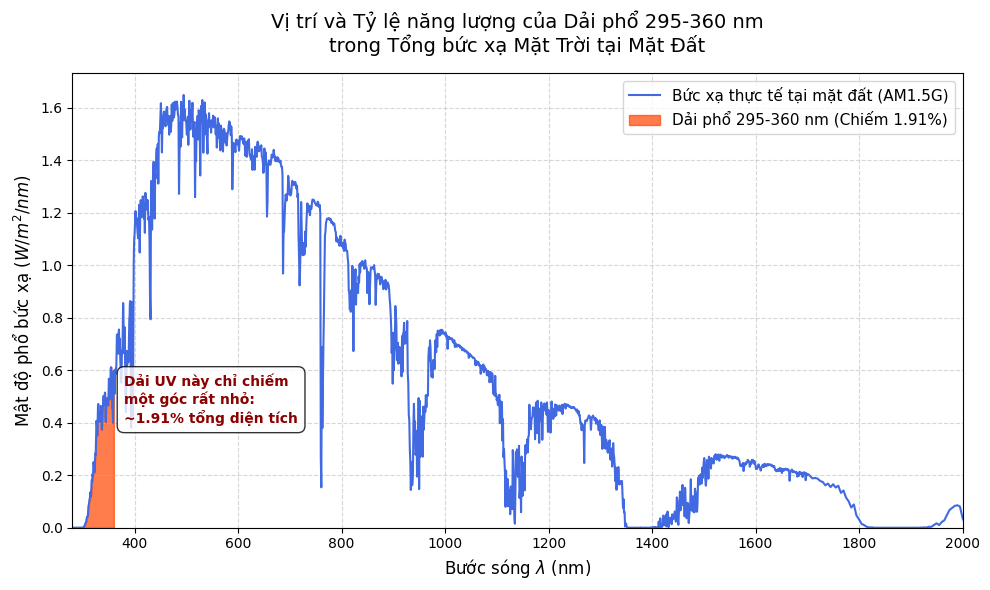

In [7]:
import pvlib
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson

# 1. Tải dữ liệu thực tế ASTM G173-03 từ pvlib
am15_data = pvlib.spectrum.get_reference_spectra(standard="ASTM G173-03")
wavelengths = am15_data.index.values    # Trục X: Bước sóng (nm)
irradiance_global = am15_data['global'].values # Trục Y: Cường độ bức xạ (W/m²/nm)

# 2. Tính toán lại tỷ lệ phần trăm để hiển thị lên tiêu đề đồ thị
uv_mask = (wavelengths >= 295) & (wavelengths <= 360)
energy_uv = simpson(y=irradiance_global[uv_mask], x=wavelengths[uv_mask])
energy_total = simpson(y=irradiance_global, x=wavelengths)
percentage = (energy_uv / energy_total) * 100

# 3. Khởi tạo biểu đồ
plt.figure(figsize=(10, 6), dpi=100)

# Vẽ đường cong tổng năng lượng bức xạ tại mặt đất
plt.plot(wavelengths, irradiance_global, color='royalblue', linewidth=1.5, label='Bức xạ thực tế tại mặt đất (AM1.5G)')

# Tô màu riêng vùng dải phổ 295 - 360 nm để thấy diện tích năng lượng
plt.fill_between(
  wavelengths, irradiance_global,
  where=uv_mask,
  color='orangered', alpha=0.7,
  label=f'Dải phổ 295-360 nm (Chiếm {percentage:.2f}%)'
)

# 4. Định dạng biểu đồ (Gắn nhãn, tiêu đề, giới hạn trục)
plt.title('Vị trí và Tỷ lệ năng lượng của Dải phổ 295-360 nm\ntrong Tổng bức xạ Mặt Trời tại Mặt Đất', fontsize=14, pad=15)
plt.xlabel('Bước sóng $\lambda$ (nm)', fontsize=12)
plt.ylabel('Mật độ phổ bức xạ ($W/m^2/nm$)', fontsize=12)

# Giới hạn trục X từ 280nm đến 2000nm để tập trung vào vùng năng lượng chính
plt.xlim(280, 2000)
plt.ylim(bottom=0)

# Thêm chú thích cho vùng tô màu
plt.text(380, 0.4, f'Dải UV này chỉ chiếm\nmột góc rất nhỏ:\n~{percentage:.2f}% tổng diện tích',
     color='darkred', fontsize=10, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))

# Bật lưới và chú thích các đường
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11, loc='upper right')

# Hiển thị biểu đồ ra màn hình
plt.tight_layout()
plt.show()

## Tạo đồ thị với dải phổ từ 295 - 385nm

<>:33: SyntaxWarning: invalid escape sequence '\l'
<>:33: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1450/1280940135.py:33: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('Bước sóng $\lambda$ (nm)', fontsize=12)


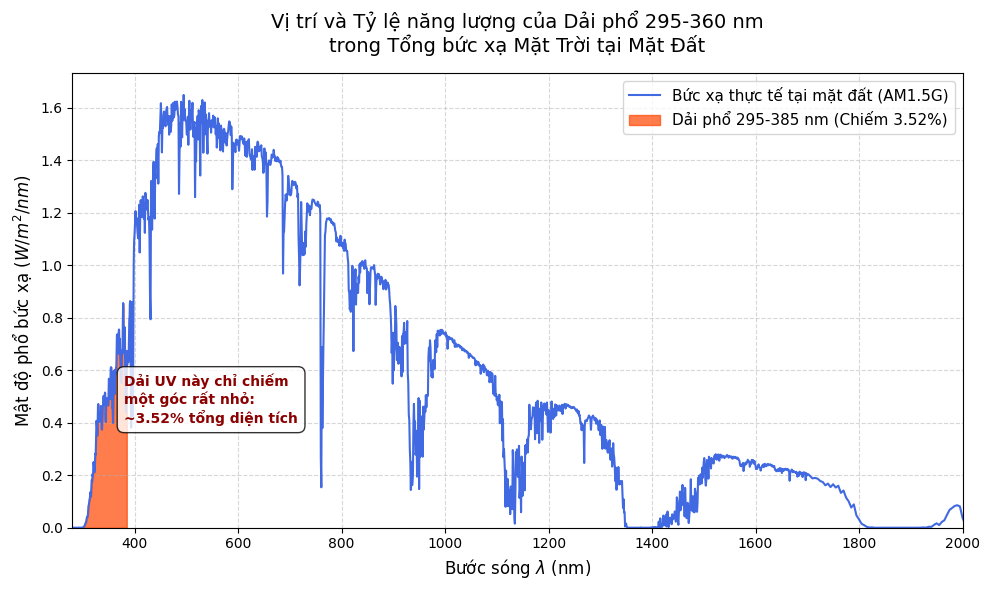

In [8]:
import pvlib
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson

# 1. Tải dữ liệu thực tế ASTM G173-03 từ pvlib
am15_data = pvlib.spectrum.get_reference_spectra(standard="ASTM G173-03")
wavelengths = am15_data.index.values    # Trục X: Bước sóng (nm)
irradiance_global = am15_data['global'].values # Trục Y: Cường độ bức xạ (W/m²/nm)

# 2. Tính toán lại tỷ lệ phần trăm để hiển thị lên tiêu đề đồ thị
uv_mask = (wavelengths >= 295) & (wavelengths <= 385)
energy_uv = simpson(y=irradiance_global[uv_mask], x=wavelengths[uv_mask])
energy_total = simpson(y=irradiance_global, x=wavelengths)
percentage = (energy_uv / energy_total) * 100

# 3. Khởi tạo biểu đồ
plt.figure(figsize=(10, 6), dpi=100)

# Vẽ đường cong tổng năng lượng bức xạ tại mặt đất
plt.plot(wavelengths, irradiance_global, color='royalblue', linewidth=1.5, label='Bức xạ thực tế tại mặt đất (AM1.5G)')

# Tô màu riêng vùng dải phổ 295 - 385 nm để thấy diện tích năng lượng
plt.fill_between(
  wavelengths, irradiance_global,
  where=uv_mask,
  color='orangered', alpha=0.7,
  label=f'Dải phổ 295-385 nm (Chiếm {percentage:.2f}%)'
)

# 4. Định dạng biểu đồ (Gắn nhãn, tiêu đề, giới hạn trục)
plt.title('Vị trí và Tỷ lệ năng lượng của Dải phổ 295-360 nm\ntrong Tổng bức xạ Mặt Trời tại Mặt Đất', fontsize=14, pad=15)
plt.xlabel('Bước sóng $\lambda$ (nm)', fontsize=12)
plt.ylabel('Mật độ phổ bức xạ ($W/m^2/nm$)', fontsize=12)

# Giới hạn trục X từ 280nm đến 2000nm để tập trung vào vùng năng lượng chính
plt.xlim(280, 2000)
plt.ylim(bottom=0)

# Thêm chú thích cho vùng tô màu
plt.text(380, 0.4, f'Dải UV này chỉ chiếm\nmột góc rất nhỏ:\n~{percentage:.2f}% tổng diện tích',
     color='darkred', fontsize=10, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))

# Bật lưới và chú thích các đường
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11, loc='upper right')

# Hiển thị biểu đồ ra màn hình
plt.tight_layout()
plt.show()

## Tạo đồ thị với dải phổ từ 295 - 350nm

<>:33: SyntaxWarning: invalid escape sequence '\l'
<>:33: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1450/773295448.py:33: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('Bước sóng $\lambda$ (nm)', fontsize=12)


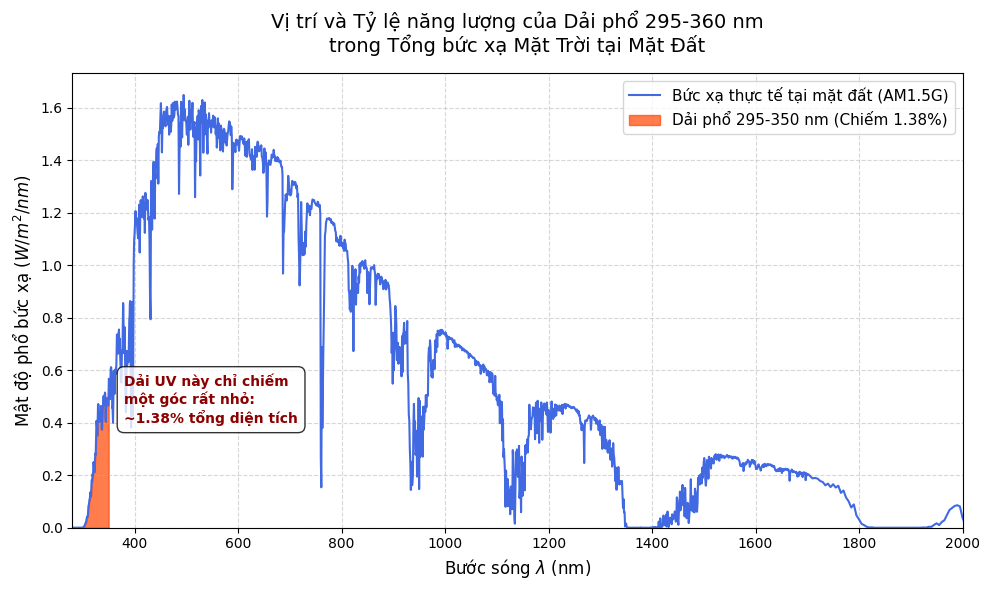

In [10]:
import pvlib
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson

# 1. Tải dữ liệu thực tế ASTM G173-03 từ pvlib
am15_data = pvlib.spectrum.get_reference_spectra(standard="ASTM G173-03")
wavelengths = am15_data.index.values    # Trục X: Bước sóng (nm)
irradiance_global = am15_data['global'].values # Trục Y: Cường độ bức xạ (W/m²/nm)

# 2. Tính toán lại tỷ lệ phần trăm để hiển thị lên tiêu đề đồ thị
uv_mask = (wavelengths >= 295) & (wavelengths <= 350)
energy_uv = simpson(y=irradiance_global[uv_mask], x=wavelengths[uv_mask])
energy_total = simpson(y=irradiance_global, x=wavelengths)
percentage = (energy_uv / energy_total) * 100

# 3. Khởi tạo biểu đồ
plt.figure(figsize=(10, 6), dpi=100)

# Vẽ đường cong tổng năng lượng bức xạ tại mặt đất
plt.plot(wavelengths, irradiance_global, color='royalblue', linewidth=1.5, label='Bức xạ thực tế tại mặt đất (AM1.5G)')

# Tô màu riêng vùng dải phổ 295 - 350 nm để thấy diện tích năng lượng
plt.fill_between(
  wavelengths, irradiance_global,
  where=uv_mask,
  color='orangered', alpha=0.7,
  label=f'Dải phổ 295-350 nm (Chiếm {percentage:.2f}%)'
)

# 4. Định dạng biểu đồ (Gắn nhãn, tiêu đề, giới hạn trục)
plt.title('Vị trí và Tỷ lệ năng lượng của Dải phổ 295-360 nm\ntrong Tổng bức xạ Mặt Trời tại Mặt Đất', fontsize=14, pad=15)
plt.xlabel('Bước sóng $\lambda$ (nm)', fontsize=12)
plt.ylabel('Mật độ phổ bức xạ ($W/m^2/nm$)', fontsize=12)

# Giới hạn trục X từ 280nm đến 2000nm để tập trung vào vùng năng lượng chính
plt.xlim(280, 2000)
plt.ylim(bottom=0)

# Thêm chú thích cho vùng tô màu
plt.text(380, 0.4, f'Dải UV này chỉ chiếm\nmột góc rất nhỏ:\n~{percentage:.2f}% tổng diện tích',
     color='darkred', fontsize=10, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))

# Bật lưới và chú thích các đường
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11, loc='upper right')

# Hiển thị biểu đồ ra màn hình
plt.tight_layout()
plt.show()